In [1]:
%matplotlib notebook
pip install matplotlib

In [3]:
import matplotlib.pyplot as plt

In [4]:
import numpy as np

In [5]:
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

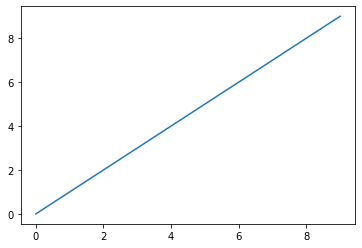

In [7]:
plt.plot(data)

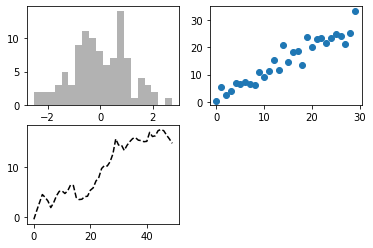

In [20]:
fig = plt.figure()
ax1 = fig.add_subplot(2, 2, 1) #크기가 2*2, 4개의 서브플롯 중 첫 번째 
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
plt.plot(np.random.randn(50).cumsum(), 'k--') #'k--' : 점선을 그리기 위한 스타일 옵션
#주피터에서는 단일 셀에 코드 전부를 입력해야지 실행
_ = ax1.hist(np.random.randn(100), bins = 20, color = 'k', alpha = 0.3)
ax2.scatter(np.arange(30), np.arange(30) + 3*np.random.randn(30))

<Figure size 432x288 with 0 Axes>

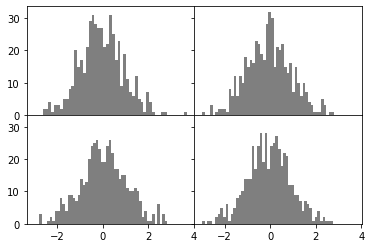

In [21]:
#서브플롯 간의 간격 조절하기 : subplots_adjust
#서브플롯 간의 간격을 주지 않은 그래프를 생성하는 코드
fig = plt.figure()
fig, axes = plt.subplots(2, 2, sharex= True, sharey= True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.randn(500), bins = 50, color = 'k', alpha = 0.5)
plt.subplots_adjust(wspace= 0, hspace= 0) #wspace : figure의 너비, hspace : figure의 높이

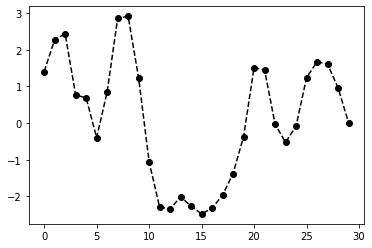

In [22]:
#matplotlib은 그래프의 색상 선을 축약 문자열로! LIKE ax.plot(x, y, 'g--') = ax.plot(x, y, linestyle = '--', color = 'g')
#마커 : 축약문자에서 색상 다음 마커 스타일 ex) 'ko--'
from numpy.random import randn
plt.plot(randn(30).cumsum(), 'ko--') #cumsum : 원소들의 누적합
# == plot(randn(30).cumsum(), color = 'k', linestyle = 'dashed', maker = 'o')

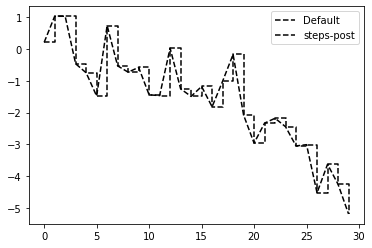

In [30]:
#선그래프에서 연속된 지점 연결 바꾸기
data = np.random.randn(30).cumsum()
plt.plot(data, 'k--', label = 'Default')
plt.plot(data, 'k--', drawstyle= 'steps-post', label = 'steps-post')
plt.legend(loc = 'best')

Text(0.5, 0, 'Stages')

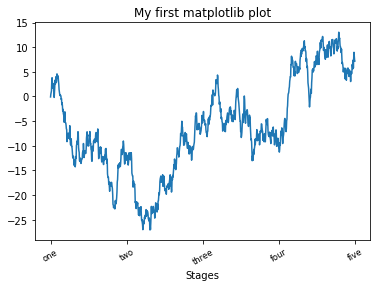

In [38]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())
#x축의 눈금 변경 : set_xticks, set_xticklabels
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(['one', 'two', 'three', 'four', 'five'],
                            rotation = 30, fontsize = 'small')
                            #set_title: 서브플롯의 제목을 지정
#set_xlabel : x축에 대한 이름을 지정
ax.set_title('My first matplotlib plot')
ax.set_xlabel('Stages')

[Text(0.5, 1.0, 'My first matplotlib plot'), Text(0.5, 0, 'Stages')]

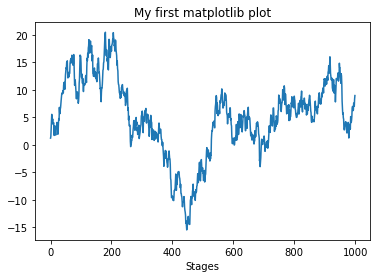

In [39]:
#x대신 y를 써서 같은 과정
#axes : 플롯의 속성을 설정할 수 있도록 set 메서드를 제공
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(np.random.randn(1000).cumsum())
props = {
    'title' : 'My first matplotlib plot',
    'xlabel' : 'Stages'
}
ax.set(**props)

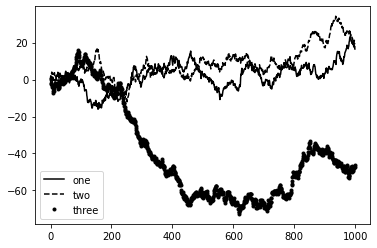

In [4]:
#범례(legend) 추가하기 -> 각 그래프에 label 인자 -> ax.lengend() or plt.legend() 실행 시 자동으로 범례 생성
import matplotlib.pyplot as plt
from numpy.random import randn
fig = plt.figure(); ax = fig.add_subplot(1, 1, 1)
ax.plot(randn(1000).cumsum(), 'k', label = 'one')
ax.plot(randn(1000).cumsum(), 'k--', label = 'two')
ax.plot(randn(1000).cumsum(), 'k.', label = 'three')
plt.legend() # = ax.lengend()
#legend의 loc 옵션 : 범례를 어디에 둘지, BUT 'best'가 가장 좋다!

In [5]:
#주석과 그림 추가 : text, arrow, annotate
#ax.text(x, y, 'Hello world!',
#        family = 'monospace', fontsize = 10)

NameError: name 'x' is not defined

Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

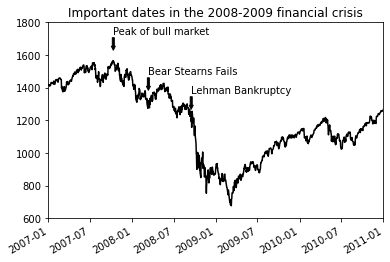

In [13]:
from datetime import datetime
import pandas as pd
from pandas import Series, DataFrame

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
data = pd.read_csv('C:/Users/seven/OneDrive/바탕 화면/Python Workspace/Python-master/Python for Data analysis/examples/spx.csv', index_col = 0,  parse_dates = True)
spx = data['SPX']

spx.plot(ax = ax, style = 'k-')

crisis_data = [
    (datetime(2007, 10, 11), 'Peak of bull market'),
    (datetime(2008, 3, 12), 'Bear Stearns Fails'),
    (datetime(2008, 9, 15), 'Lehman Bankruptcy')
]
for date, label in crisis_data:
    ax.annotate(label, xy = (date, spx.asof(date) + 75), #annotate : x, y로 지정한 위치에 라벨을 추가
    xytext = (date, spx.asof(date) + 225),
    arrowprops = dict(facecolor = 'black', headwidth = 4, width = 2, headlength = 4),
    horizontalalignment = 'left', verticalalignment = 'top')
#2007- 2010 구간으로 확대
ax.set_xlim(['1/1/2007', '1/1/2011']) #x축 그래프 경계 설정
ax.set_ylim([600, 1800]) #y축 그래프 경계 설정

ax.set_title('Important dates in the 2008-2009 financial crisis') #그래프의 제목 지정

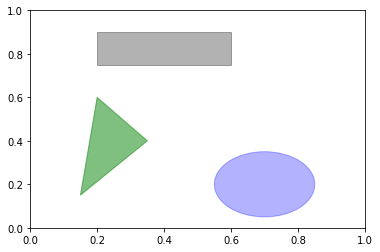

In [14]:
#patches: 일반적인 도형 표현
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color = 'k', alpha = 0.3)
circ = plt.Circle((0.7, 0.2), 0.15, color = 'b', alpha = 0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                    color = 'g', alpha = 0.5)

ax.add_patch(rect)
ax.add_patch(circ) 
ax.add_patch(pgon)

In [15]:
#plt.savefig : 그래프 파일로 저장
plt.savefig('figpath.png', dpi = 400, bbox_inches = 'tight')

<Figure size 432x288 with 0 Axes>

In [19]:
from io import BytesIO
buffer = BytesIO()
plt.savefig(buffer)
plot_data = buffer.getvalue()

<Figure size 432x288 with 0 Axes>

In [20]:
import pandas as pd
import numpy as np
from pandas import Series, DataFrame

<AxesSubplot:>

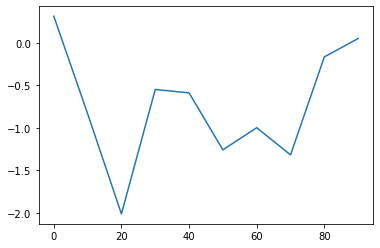

In [23]:
s = pd.Series(np.random.randn(10).cumsum(), index= np.arange(0, 100, 10))
s.plot()
# Series에서 인덱스는 matplotlib에서 x축으로 해석/use_index = False : 인덱스를 그래프의 축으로 사용 X

<AxesSubplot:>

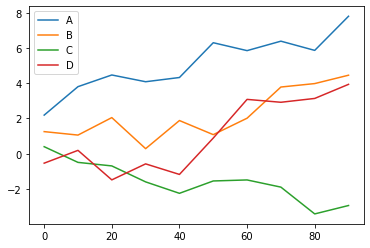

In [29]:
df = pd.DataFrame(np.random.randn(10, 4).cumsum(0), # cumsum( axis = 0) : 컬럼끼리 누적합
                    columns=['A', 'B', 'C', 'D'],
                    index = np.arange(0, 100, 10))
df.plot()

<AxesSubplot:>

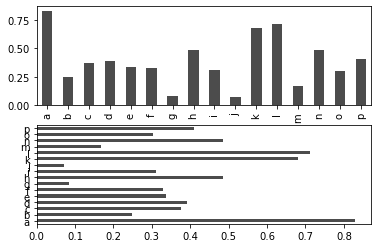

In [31]:
#plot.bar(): 수직 막대그래프, plot.barh() : 수평막대그래프
fig, axes = plt.subplots(2, 1)
data = pd.Series(np.random.rand(16), index = list('abcdefghijklmnop'))

data.plot.bar(ax = axes[0], color = 'k', alpha = 0.7) # index : x눈금 , alpha : 투명도
data.plot.barh(ax = axes[1], color = 'k', alpha = 0.7) # index : y눈금

In [35]:
df = pd.DataFrame(np.random.rand(6,4),
                index=['one', 'two', 'three', 'four', 'five', 'six'],
                columns = pd.Index(['A', 'B', 'C', 'D'], name='Genus'))
df

Genus,A,B,C,D
one,0.045164,0.846438,0.485042,0.802123
two,0.568369,0.110851,0.634979,0.348571
three,0.086755,0.351514,0.976317,0.287841
four,0.842353,0.266643,0.926944,0.295666
five,0.912185,0.106372,0.240336,0.510331
six,0.226637,0.762728,0.089111,0.896970


<AxesSubplot:>

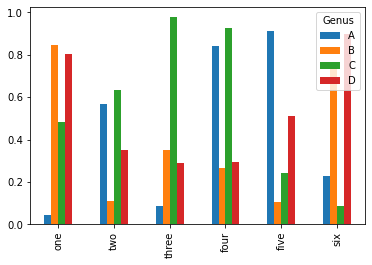

In [36]:
df.plot.bar()

<AxesSubplot:>

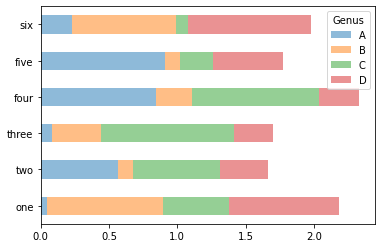

In [37]:
#누적 막대 그래프 : stacked = True 옵션으로 설정 -> 각 로우의 값들이 하나의 막대에 누적되어 출력
df.plot.barh(stacked = True, alpha = 0.5)

In [42]:
tips = pd.read_csv('C:/Users/seven/OneDrive/바탕 화면/Python Workspace/Python-master/Python for Data analysis/examples/tips.csv')
party_counts = pd.crosstab(tips['day'], tips['size']) # size: 파티의 규모
party_counts

size,1,2,3,4,5,6
day,,,,,,
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1
Thur,1,48,4,5,1,3


In [44]:
party_counts = party_counts.loc[:, 2:5]

In [45]:
#합이 1이 되도록 정규화
party_pcts = party_counts.div(party_counts.sum(1), axis = 0) #div : 데이터 전체를 지정된 인스턴스로 나눌때, axis = 0 : row 기준 계산
party_pcts

size,2,3,4,5
day,,,,
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000
Thur,0.827586,0.068966,0.086207,0.017241


<AxesSubplot:xlabel='day'>

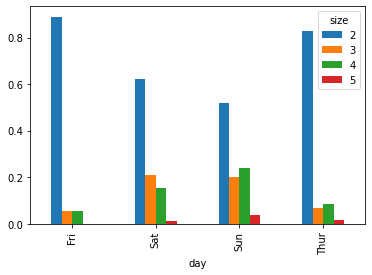

In [46]:
party_pcts.plot.bar()

In [47]:
import seaborn as sns
tips['tip_pct'] = tips['tip']/(tips['total_bill'] - tips['tip'])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<AxesSubplot:xlabel='tip_pct', ylabel='day'>

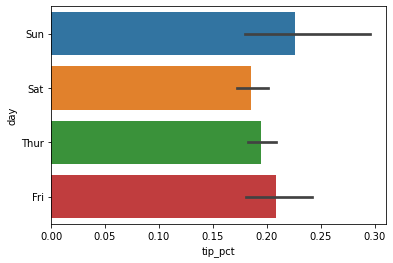

In [48]:
#에러 막대를 포함한 요일별 팁 비율 그래프
sns.barplot(x = 'tip_pct', y = 'day', data = tips, orient = 'h') 
#검은 선 : 95% C.I, 평균값으로 막대 그래프

<AxesSubplot:xlabel='tip_pct', ylabel='day'>

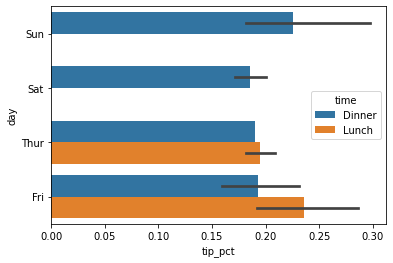

In [49]:
sns.barplot(x = 'tip_pct', y = 'day', hue = 'time', data = tips, orient= 'h') # hue : 추가 분류에 따라 나눠 그릴 수 있음

<AxesSubplot:ylabel='Frequency'>

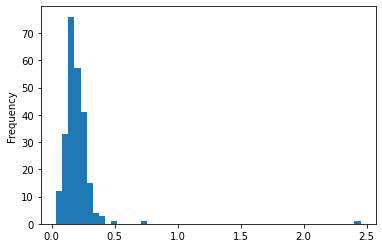

In [50]:
#히스토그램 : 막대그래프의 한 종류, '빈도'를 분리해서 보여줌
#데이터의 숫자가 막대의 높이로 표현
tips['tip_pct'].plot.hist(bins = 50)

<AxesSubplot:ylabel='Density'>

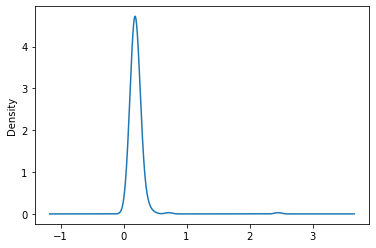

In [52]:
# 밀도그래프(KDE) : 관찰값을 사용해서 추정되는 연속된 확률 분포를 그림 메서드 : plot.kde
tips['tip_pct'].plot.density()

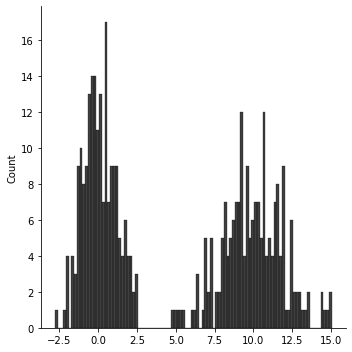

In [62]:
 #displot : 히스토그램과 밀도 그래프를 한 번에
 comp1 = np.random.normal(0, 1, size = 200)
 comp2 = np.random.normal(10, 2, size = 200)
 values = pd.Series(np.concatenate([comp1, comp2])) #concatenate : 배열 합치기
 sns.displot(values, bins = 100, color = 'k')

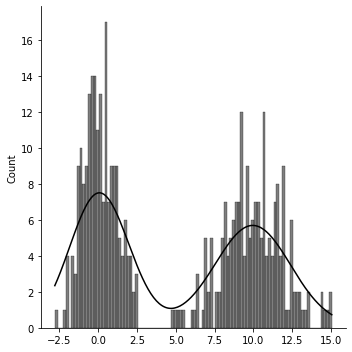

In [63]:
sns.displot(values, bins = 100, color = 'k', kde = True)

In [64]:
macro = pd.read_csv('C:/Users/seven/OneDrive/바탕 화면/Python Workspace/Python-master/Python for Data analysis/examples/macrodata.csv')
macro

,year,quarter,realgdp,realcons,realinv,realgovt,realdpi,cpi,m1,tbilrate,unemp,pop,infl,realint
0,1959.0,1.0,2710.349,1707.4,286.898,470.045,1886.9,28.980,139.7,2.82,5.8,177.146,0.00,0.00
1,1959.0,2.0,2778.801,1733.7,310.859,481.301,1919.7,29.150,141.7,3.08,5.1,177.830,2.34,0.74
2,1959.0,3.0,2775.488,1751.8,289.226,491.260,1916.4,29.350,140.5,3.82,5.3,178.657,2.74,1.09
3,1959.0,4.0,2785.204,1753.7,299.356,484.052,1931.3,29.370,140.0,4.33,5.6,179.386,0.27,4.06
4,1960.0,1.0,2847.699,1770.5,331.722,462.199,1955.5,29.540,139.6,3.50,5.2,180.007,2.31,1.19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198,2008.0,3.0,13324.600,9267.7,1990.693,991.551,9838.3,216.889,1474.7,1.17,6.0,305.270,-3.16,4.33
199,2008.0,4.0,13141.920,9195.3,1857.661,1007.273,9920.4,212.174,1576.5,0.12,6.9,305.952,-8.79,8.91
200,2009.0,1.0,12925.410,9209.2,1558.494,996.287,9926.4,212.671,1592.8,0.22,8.1,306.547,0.94,-0.71
201,2009.0,2.0,12901.504,9189.0,1456.678,1023.528,10077.5,214.469,1653.6,0.18,9.2,307.226,3.37,-3.19


In [66]:
data = macro[['cpi', 'm1', 'tbilrate', 'unemp']]
trans_data = np.log(data).diff().dropna()
trans_data

,cpi,m1,tbilrate,unemp
1,0.005849,0.014215,0.088193,-0.128617
2,0.006838,-0.008505,0.215321,0.038466
3,0.000681,-0.003565,0.125317,0.055060
4,0.005772,-0.002861,-0.212805,-0.074108
5,0.000338,0.004289,-0.266946,0.000000
...,...,...,...,...
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339


C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0.5, 1.0, 'Changes in log m1 versus log unemp')

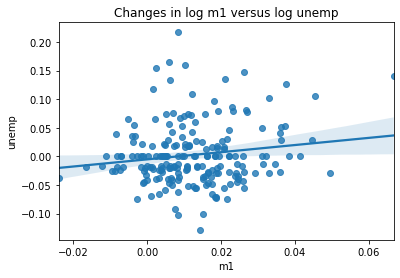

In [69]:
#regplot : 산포도와 선형회귀곡선
sns.regplot('m1', 'unemp', data = trans_data)
plt.title('Changes in log {0} versus log {1}'.format('m1', 'unemp'))

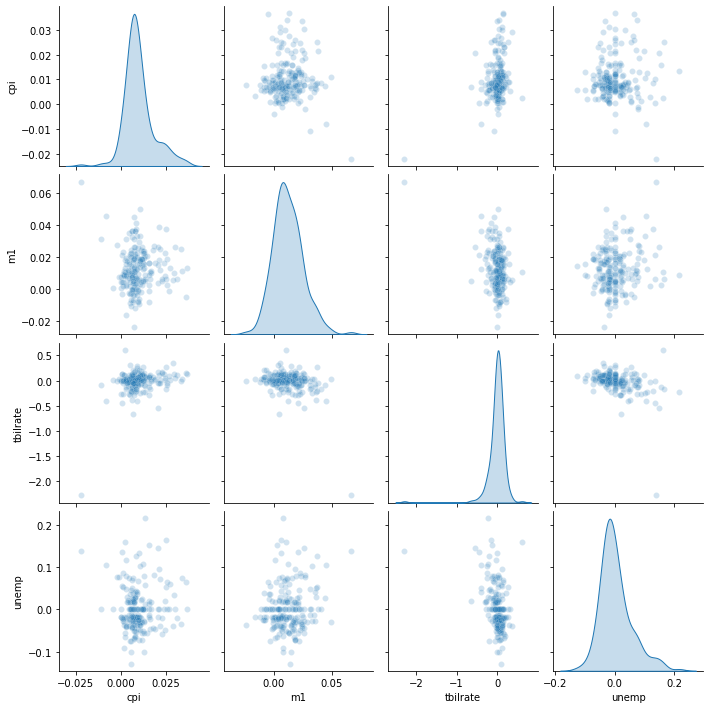

In [70]:
#EDA에선 변수 그룹 간의 모든 산포도를 살펴보는 일이 매우 유용
# => 짝지은 그래프 or 산포도 행렬이라고 함
#pairplot :대각선을 따라 각 변수에 대한 히스토그램이나 밀도 그래프를 생성
sns.pairplot(trans_data, diag_kind='kde', plot_kws={'alpha' : 0.2}) #plot_kws : 그래프에 전달한 개별 설정값을 지정

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


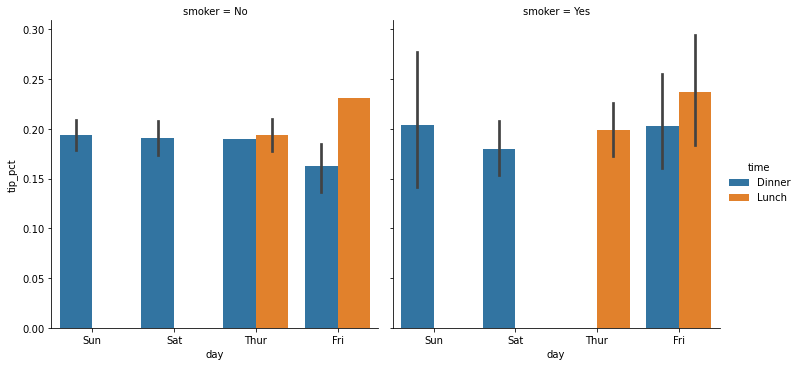

In [71]:
# 패싯 그리드 : 다양한 범주형 값을 가지는 데이터를 시각화하는 방법 => factorplot
sns.factorplot(x = 'day', y = 'tip_pct', hue = 'time', col = 'smoker',
                kind = 'bar', data = tips[tips.tip_pct < 1]) #요일/시간/흡연 여부에 따른 팁 비율

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


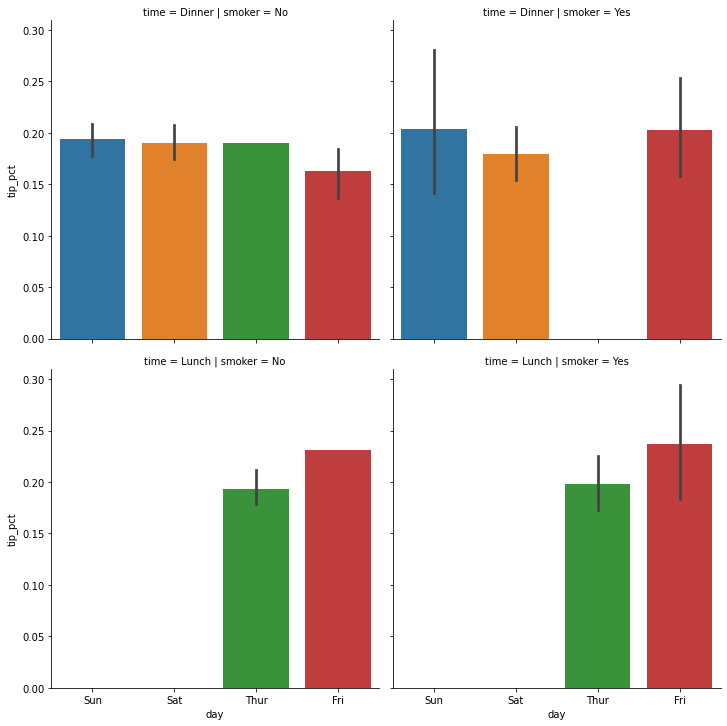

In [72]:
#패싯 그리드에 time 값에 따른 그래프를 추가
sns.factorplot(x = 'day', y = 'tip_pct', row = 'time', 
                col = 'smoker', kind = 'bar', data = tips[tips.tip_pct < 1])

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\categorical.py:3704: UserWarning: The `factorplot` function has been renamed to `catplot`. The original name will be removed in a future release. Please update your code. Note that the default `kind` in `factorplot` (`'point'`) has changed `'strip'` in `catplot`.
  warnings.warn(msg)


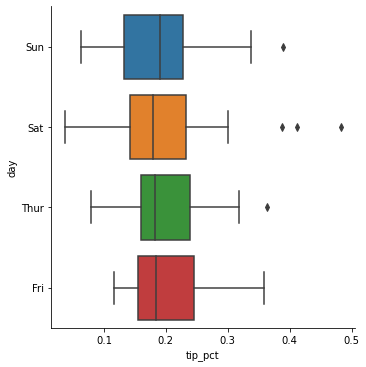

In [73]:
#box plot
sns.factorplot( x = 'tip_pct', y = 'day', kind = 'box', data = tips[tips.tip_pct < 0.5])